
# GRB Cluster Analysis (with Outliers)

This notebook analyzes how your unsupervised model clustered the GRB dataset.

- **Cluster 0 and 1** = the two main clusters  
- **Cluster -1** = outliers (treated separately)  

We’ll check whether clusters align with **short vs. long GRBs (T90)**, visualize latent space, and inspect representative bursts.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, mutual_info_score

try:
    from scipy.stats import ks_2samp, f_oneway
    SCIPY_OK = True
except ImportError:
    SCIPY_OK = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (8,5)


In [2]:

clusters = pd.read_csv("clustered_with_durations.csv")
clusters = clusters.rename(columns={"cluster_label":"cluster"})

burst_list = np.load("burst_list.npy", allow_pickle=True)
latent_feats = np.load("latent_feats.npy")

# Align burst_id with latent_feats order
lf_df = pd.DataFrame({"burst_id": burst_list, "idx_latent": np.arange(len(burst_list))})
df = clusters.merge(lf_df, on="burst_id", how="inner").sort_values("idx_latent").reset_index(drop=True)
df["latent"] = [latent_feats[i] for i in df["idx_latent"].values]

print("DataFrame:", df.shape)
df.head()


DataFrame: (2930, 5)


,burst_id,cluster,duration,idx_latent,latent
0,80714745,0,59.6,0,"[0.014233854, 0.16969196, 0.09715636, -0.06431..."
1,80715950,1,7.9,1,"[0.010164218, 0.1657818, 0.08654164, -0.057353..."
2,80717543,0,36.6,2,"[0.014033141, 0.16956018, 0.09815084, -0.06534..."
3,80719529,0,16.1,3,"[0.013852473, 0.17023124, 0.0984739, -0.067268..."
4,80723557,1,58.4,4,"[0.005192327, 0.16101377, 0.09163956, -0.05960..."


## Duration Distributions by Cluster (T90 in seconds)

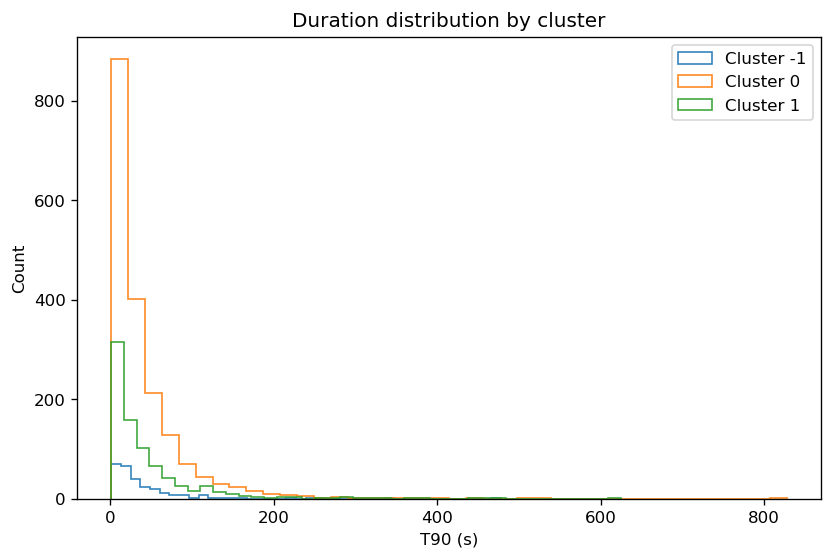

C:\Users\tobys\AppData\Local\Temp\ipykernel_29108\3685266584.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(c) for c in main_clusters])


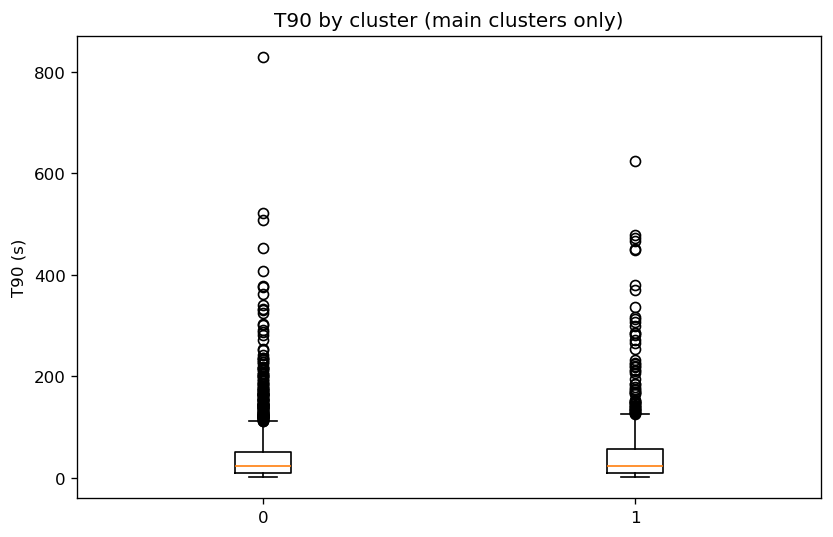

In [3]:

fig, ax = plt.subplots()
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.hist(df.loc[mask,'duration'], bins=40, histtype='step', label=f'Cluster {c}', alpha=0.9)
ax.set_xlabel("T90 (s)")
ax.set_ylabel("Count")
ax.set_title("Duration distribution by cluster")
ax.legend()
plt.show()

# Boxplot (excluding outliers for clearer view)
fig, ax = plt.subplots()
main_clusters = [0,1]
data = [df.loc[df['cluster']==c,'duration'].values for c in main_clusters]
ax.boxplot(data, labels=[str(c) for c in main_clusters])
ax.set_title("T90 by cluster (main clusters only)")
ax.set_ylabel("T90 (s)")
plt.show()


## Statistical Tests Between Main Clusters (0 vs 1)

In [4]:

if SCIPY_OK:
    d0 = df.loc[df['cluster']==0, 'duration'].dropna()
    d1 = df.loc[df['cluster']==1, 'duration'].dropna()
    if len(d0)>2 and len(d1)>2:
        ks, pks = ks_2samp(d0, d1)
        print(f"KS-test 0 vs 1: KS={ks:.3f}, p={pks:.2e}")
    if len(d0)>2 and len(d1)>2:
        F, p = f_oneway(d0, d1)
        print(f"ANOVA 0 vs 1: F={F:.3f}, p={p:.2e}")
else:
    print("SciPy not available.")


KS-test 0 vs 1: KS=0.031, p=6.45e-01
ANOVA 0 vs 1: F=4.086, p=4.33e-02


## Latent Space Visualization (PCA and t-SNE)

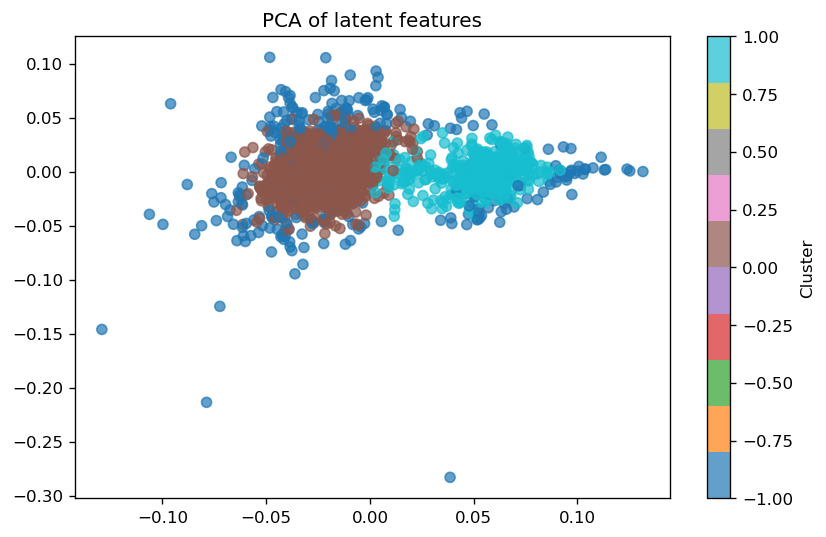

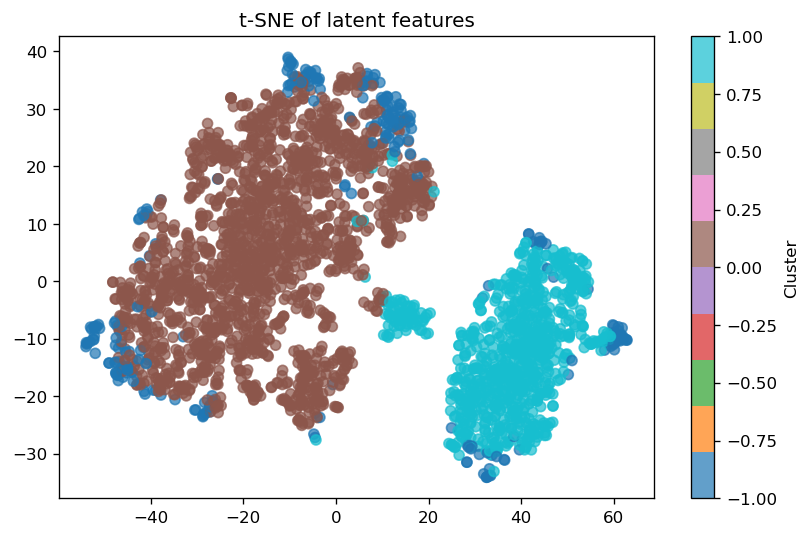

In [5]:

latent = np.vstack(df["latent"].values)

# PCA
pca = PCA(n_components=2, random_state=42)
Zp = pca.fit_transform(latent)

fig, ax = plt.subplots()
sc = ax.scatter(Zp[:,0], Zp[:,1], c=df['cluster'], cmap='tab10', alpha=0.7)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_title("PCA of latent features")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init="pca")
Zt = tsne.fit_transform(latent)

fig, ax = plt.subplots()
sc = ax.scatter(Zt[:,0], Zt[:,1], c=df['cluster'], cmap='tab10', alpha=0.7)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_title("t-SNE of latent features")
plt.show()


## Representative Bursts Per Cluster

In [6]:

top_k = 5
reps = []
for c in sorted(df['cluster'].unique()):
    mask = df['cluster']==c
    Xc = np.vstack(df.loc[mask,'latent'].values)
    if Xc.shape[0]==0: continue
    centroid = Xc.mean(axis=0, keepdims=True)
    D = pairwise_distances(Xc, centroid).ravel()
    idxs = df.loc[mask].iloc[np.argsort(D)[:top_k]]
    reps.append(idxs[['burst_id','cluster','duration']])

pd.concat(reps)


,burst_id,cluster,duration
1817,181020792,-1,15.1
1538,170414551,-1,45.8
1703,180401846,-1,23.0
2918,241029097,-1,13.3
1188,150513856,-1,159.0
2237,210120299,0,22.2
1858,190131964,0,63.2
341,100619015,0,96.0
2761,231126050,0,14.8
274,100201588,0,141.1



## Visual check: representative light curves per cluster

This section pulls the **top-k bursts nearest each cluster centroid** in latent space,
loads their **light curves from `Bursts.zip`**, averages across detectors (after simple
normalization), and plots the mean light curve per representative burst.


Found light curve files for 2930 bursts.


,burst_id,cluster,duration,rank
1817,181020792,-1,15.1,1
1538,170414551,-1,45.8,2
1703,180401846,-1,23.0,3
2237,210120299,0,22.2,1
1858,190131964,0,63.2,2
341,100619015,0,96.0,3
1650,171117515,1,105.9,1
2625,230307656,1,34.6,2
97,90225009,1,2.2,3


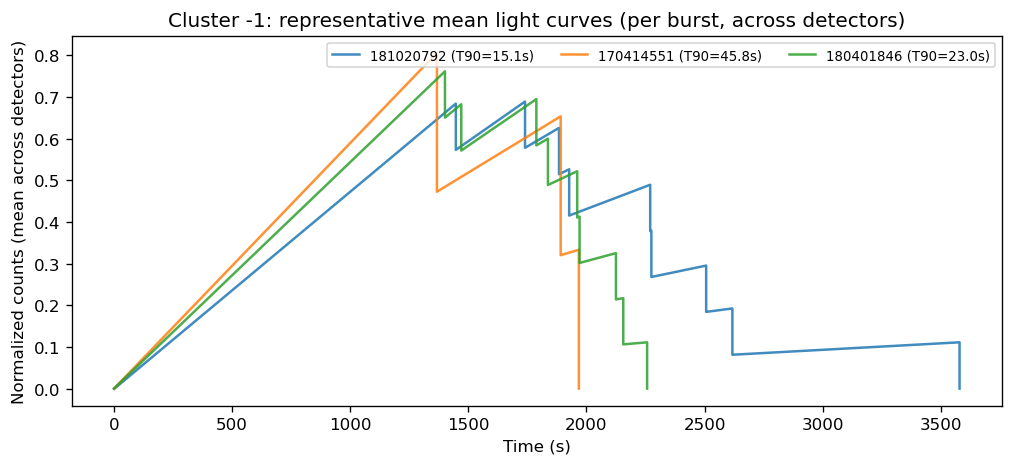

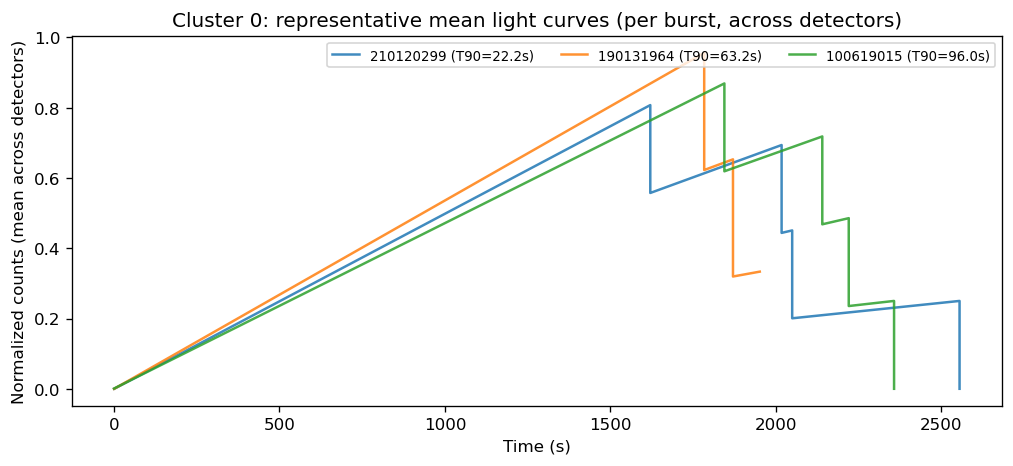

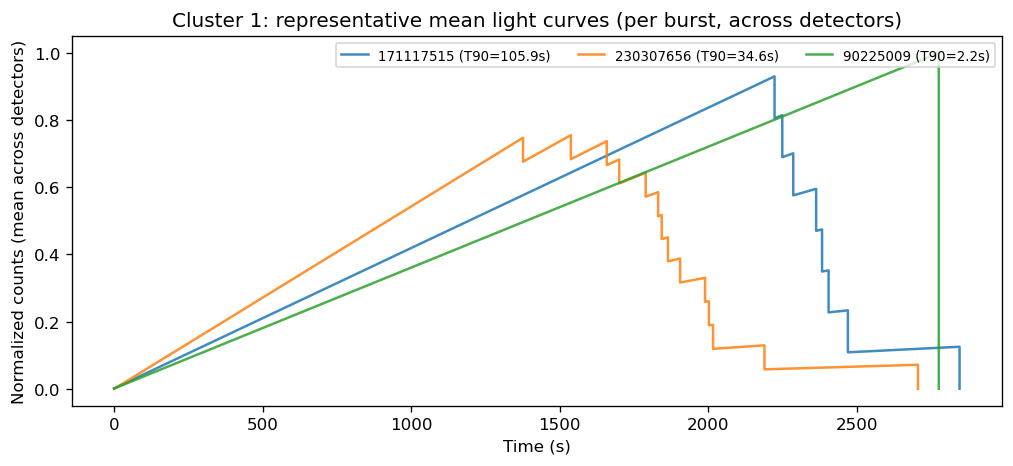

In [9]:

import os, zipfile, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# --- Use the existing Bursts directory ---
BURSTS_DIR = "Bursts"

# Map burst_id -> list of lc files
burst_files = {}
for root, _, files in os.walk(BURSTS_DIR):
    for f in files:
        if f.startswith("lc_") and f.endswith(".txt"):
            # lc_{burst}_{det}_{t90_start}_{t90}_{SNR}.txt
            parts = f[:-4].split('_')
            if len(parts) >= 6:
                try:
                    bid = int(parts[1])
                except:
                    continue
                burst_files.setdefault(bid, []).append(os.path.join(root, f))

print(f"Found light curve files for {len(burst_files)} bursts.")

# --- Helper: load and average channels with interpolation ---
DT = 0.002048  # 2.048 ms per bin (approximate grid if time column missing)
def read_lc_file(path):
    """Returns (t, y) from a single lc file.
    Tries to read two columns (t, counts). If only one column is present,
    synthesize the time axis using DT.
    """
    try:
        data = np.loadtxt(path, ndmin=2)
    except Exception as e:
        # Fallback: skip bad file
        return None, None
    if data.ndim == 1:
        data = data[None, :]
    if data.shape[1] >= 2:
        t = data[:,0].astype(float)
        y = data[:,1].astype(float)
    else:
        y = data[:,0].astype(float)
        t = np.arange(len(y))*DT
    return t, y

def mean_curve_for_burst(burst_id, grid_dt=DT, norm="max"):
    """Load all lc files for a burst, normalize each channel, align on a common grid,
    and return (t_grid, mean_curve). If nothing could be loaded, returns (None, None)."""
    files = burst_files.get(burst_id, [])
    curves = []
    max_t = 0.0
    # first pass: read and track max time
    for p in files:
        t, y = read_lc_file(p)
        if t is None: 
            continue
        if norm == "max":
            m = np.max(np.abs(y)) if np.max(np.abs(y))>0 else 1.0
            y = y / m
        elif norm == "z":
            std = np.std(y) if np.std(y)>0 else 1.0
            y = (y - np.mean(y)) / std
        curves.append((t, y))
        if len(t)>0:
            max_t = max(max_t, float(t[-1]))
    if not curves:
        return None, None
    # build grid
    n = int(np.ceil(max_t/grid_dt))+1
    t_grid = np.arange(n)*grid_dt
    # interpolate each curve to grid
    Y = []
    for (t,y) in curves:
        if len(t) < 2: 
            continue
        # ensure strictly increasing
        order = np.argsort(t)
        t_sorted = t[order]
        y_sorted = y[order]
        # dedupe
        keep = np.concatenate([[True], np.diff(t_sorted)>0])
        t_sorted = t_sorted[keep]
        y_sorted = y_sorted[keep]
        y_interp = np.interp(t_grid, t_sorted, y_sorted, left=0.0, right=0.0)
        Y.append(y_interp)
    if not Y:
        return None, None
    mean_curve = np.mean(np.vstack(Y), axis=0)
    return t_grid, mean_curve

# --- Choose representatives per cluster ---
top_k = 3
rep_rows = []
for c in sorted(df['cluster'].unique()):
    mask = (df['cluster']==c)
    Xc = np.vstack(df.loc[mask,'latent'].values)
    if Xc.shape[0]==0: 
        continue
    centroid = Xc.mean(axis=0, keepdims=True)
    D = pairwise_distances(Xc, centroid).ravel()
    order = np.argsort(D)[:top_k]
    reps = df.loc[mask].iloc[order][['burst_id','cluster','duration']].copy()
    reps['rank'] = np.arange(1, len(reps)+1)
    rep_rows.append(reps)

rep_table = pd.concat(rep_rows).sort_values(['cluster','rank'])
display(rep_table)

# --- Plot representative mean curves per cluster ---
for c in sorted(df['cluster'].unique()):
    reps = rep_table[rep_table['cluster']==c]
    if reps.empty:
        continue
    fig, ax = plt.subplots(figsize=(10,4))
    for _, row in reps.iterrows():
        bid = int(row['burst_id'])
        t, m = mean_curve_for_burst(bid, norm="max")
        if t is None:
            continue
        ax.plot(t, m, alpha=0.85, label=f"{bid} (T90={row['duration']:.1f}s)")
    ax.set_title(f"Cluster {c}: representative mean light curves (per burst, across detectors)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Normalized counts (mean across detectors)")
    ax.legend(ncol=3, fontsize=8, loc="upper right")
    plt.show()


### (Optional) Per-cluster average over representatives

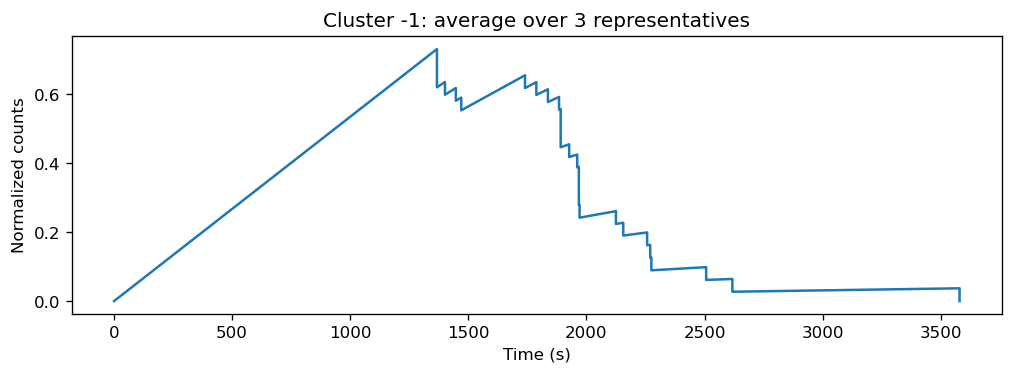

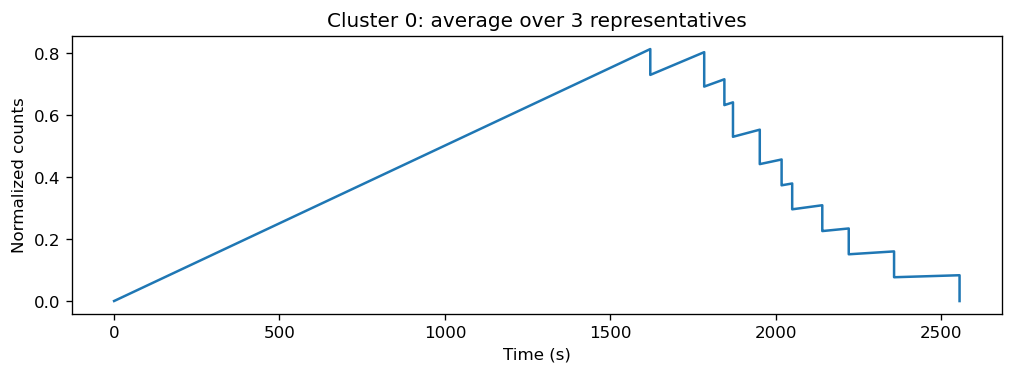

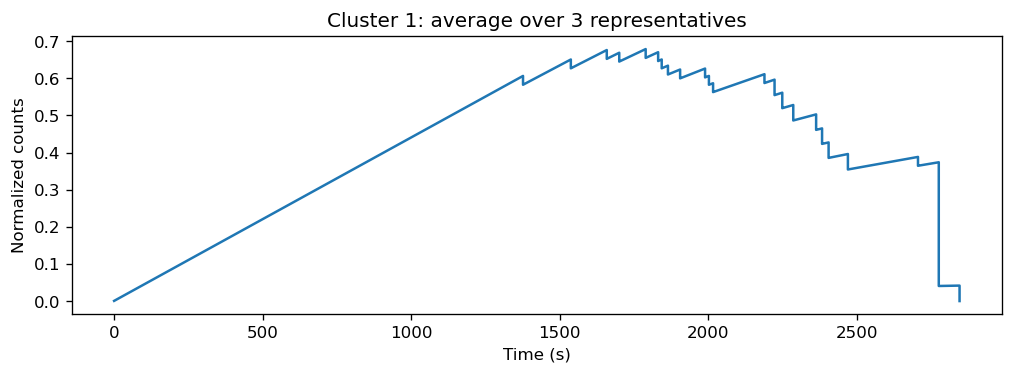

In [10]:

DT = 0.002048
def cluster_avg_from_reps(cluster_id, grid_dt=DT):
    reps = rep_table[rep_table['cluster']==cluster_id]
    if reps.empty: return None, None
    curves = []
    max_t = 0.0
    for _, row in reps.iterrows():
        t, m = mean_curve_for_burst(int(row['burst_id']), norm="max")
        if t is None: continue
        curves.append((t,m))
        if len(t)>0:
            max_t = max(max_t, float(t[-1]))
    if not curves: return None, None
    n = int(np.ceil(max_t/grid_dt))+1
    t_grid = np.arange(n)*grid_dt
    Y = []
    for (t,m) in curves:
        order = np.argsort(t)
        t = t[order]; m = m[order]
        keep = np.concatenate([[True], np.diff(t)>0])
        t = t[keep]; m = m[keep]
        Y.append(np.interp(t_grid, t, m, left=0.0, right=0.0))
    mean_curve = np.mean(np.vstack(Y), axis=0)
    return t_grid, mean_curve

for cid in sorted(df['cluster'].unique()):
    t, mc = cluster_avg_from_reps(cid)
    if t is None: 
        continue
    plt.figure(figsize=(10,3))
    plt.plot(t, mc, linewidth=1.5)
    plt.title(f"Cluster {cid}: average over {len(rep_table[rep_table['cluster']==cid])} representatives")
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized counts")
    plt.show()


In [ ]:
import os
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd

# --- Find all burst_ids that actually have lc files ---
available_ids = set()
for root, _, fs in os.walk("Bursts"):
    for f in fs:
        if f.startswith("lc_") and f.endswith(".txt"):
            parts = f.split("_")
            if len(parts) >= 6:
                try:
                    available_ids.add(int(parts[1]))
                except:
                    pass

print(f"Found {len(available_ids)} bursts with available light curves.")

# --- Filter df to only those bursts ---
df_avail = df[df["burst_id"].isin(available_ids)].copy()
print(f"{len(df_avail)} bursts available in df (out of {len(df)})")

# --- Pick representatives per cluster (nearest to centroid) ---
top_k = 3
rep_rows = []
for c in sorted(df_avail["cluster"].unique()):
    mask = df_avail["cluster"] == c
    Xc = np.vstack(df_avail.loc[mask,"latent"].values)
    if Xc.shape[0] == 0:
        continue
    centroid = Xc.mean(axis=0, keepdims=True)
    D = pairwise_distances(Xc, centroid).ravel()
    order = np.argsort(D)[:top_k]
    reps = df_avail.loc[mask].iloc[order][["burst_id","cluster","duration"]].copy()
    reps["rank"] = np.arange(1, len(reps)+1)
    rep_rows.append(reps)

rep_table = pd.concat(rep_rows).sort_values(["cluster","rank"])
display(rep_table)



Found 2930 bursts with available light curves.
2930 bursts available in df (out of 2930)


,burst_id,cluster,duration,rank
1817,181020792,-1,15.1,1
1538,170414551,-1,45.8,2
1703,180401846,-1,23.0,3
2237,210120299,0,22.2,1
1858,190131964,0,63.2,2
341,100619015,0,96.0,3
1650,171117515,1,105.9,1
2625,230307656,1,34.6,2
97,90225009,1,2.2,3
